Using 277 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Using device: cuda
加载数据与标准化器...
加载模型权重...
开始计算 SHAP 值...


  0%|          | 0/277 [00:00<?, ?it/s]

正在生成图表...


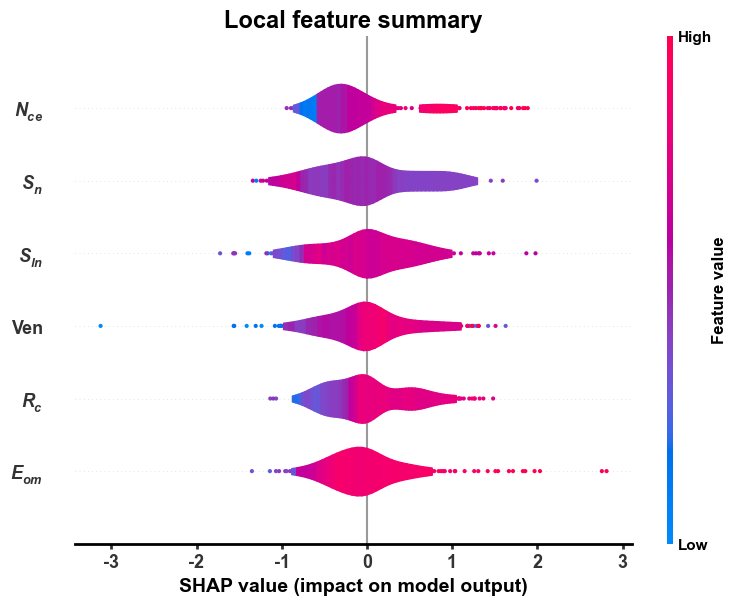

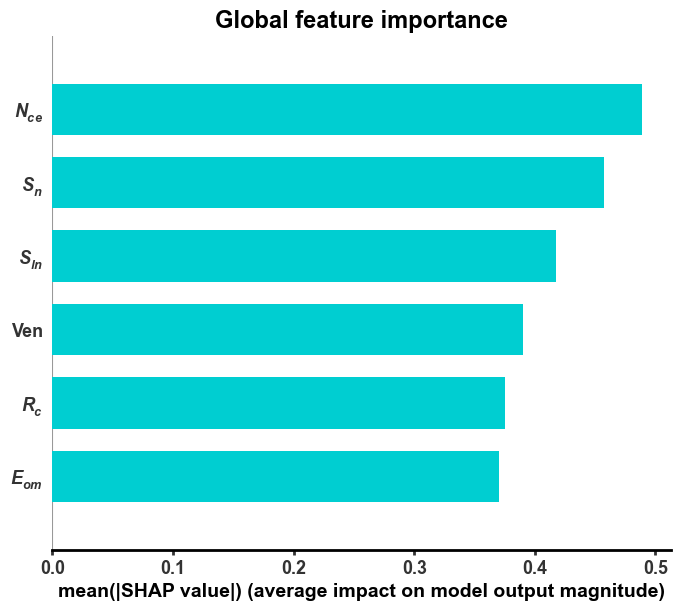

SHAP 分析完成！图片已保存。


In [8]:
# ================= 0. 跨目录寻径 (必须放在最前面) =================
import sys
import os

# 获取当前 notebook 的绝对路径的上一级目录（即项目根目录）
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# 将项目根目录添加到系统搜索路径中
if project_root not in sys.path:
    sys.path.append(project_root)
# ===============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

# 现在可以成功导入了
from src.efficient_kan import KAN  

# ================= 1. 重定义模型结构 (保持不变) =================
class Expert(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(Expert, self).__init__()
        self.fc1 = KAN([input_dim, hidden_dim, output_dim])
        
    def forward(self, x):
        x = self.fc1(x)
        return x

class MoE(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_experts=4):
        super(MoE, self).__init__()
        self.num_experts = num_experts
        self.experts = nn.ModuleList([Expert(input_dim, hidden_dim, output_dim) for _ in range(num_experts)])
        self.gate = nn.Linear(input_dim, num_experts)
        
    def forward(self, x, return_gate_weights=False):
        gate_scores = self.gate(x)
        gate_probs = F.softmax(gate_scores, dim=-1)
        expert_outputs = torch.stack([expert(x) for expert in self.experts], dim=1)
        output = torch.einsum('be,beo->bo', gate_probs, expert_outputs)
        
        if return_gate_weights:
            return output, gate_probs
        return output

class SimpleMoE(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_experts, output_dim=1):
        super(SimpleMoE, self).__init__()
        self.moe = MoE(input_dim, hidden_dim, output_dim, num_experts)
        
    def forward(self, x, return_gate_weights=False):
        if return_gate_weights:
            output, gate_probs = self.moe(x, return_gate_weights=True)
            return output.squeeze(-1), gate_probs
        else:
            output = self.moe(x)
            return output.squeeze(-1)

# ================= 2. 配置与加载 =================
def run_shap_analysis():
    # --- 配置参数 (修正为相对路径) ---
    params = {
        'hidden_dim': 39,
        'num_experts': 5,
        'model_path': '../models/model.pth',     # 返回上一级进入 models
        'scaler_path': '../models/scaler.pkl',   # 返回上一级进入 models
        'data_path': '../data/dataset.csv'      # 假设数据在 data 文件夹下，如果在其他地方请修改
    }
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # --- A. 加载数据与Scaler ---
    print("加载数据与标准化器...")
    try:
        df = pd.read_csv(params['data_path']).dropna()
    except FileNotFoundError:
        print(f"❌ 找不到数据文件 {params['data_path']}，请确保文件在该路径下！")
        return
        
    feature_names = df.columns[:-1].tolist() 

    # =========== 批量替换特征名称 (LaTeX) ===========
    name_mapping = {
        "Eom": "$E_{om}$",  
        "Nce": "$N_{ce}$",
        "Mcs": "$M_{cs}$",
        "Rc":  "$R_{c}$",
        "Sln":  "$S_{ln}$",
        "Sn":  "$S_{n}$"
    }
    feature_names = [name_mapping.get(name, name) for name in feature_names]

    X_raw = df.iloc[:, :-1].values
    scaler = joblib.load(params['scaler_path'])
    X_scaled = scaler.transform(X_raw)
    X_tensor = torch.FloatTensor(X_scaled).to(device)

    # --- B. 加载模型 ---
    print("加载模型权重...")
    input_dim = X_scaled.shape[1]
    model = SimpleMoE(input_dim, params['hidden_dim'], params['num_experts']).to(device)
    model.load_state_dict(torch.load(params['model_path'], map_location=device))
    model.eval()

    # ================= 3. SHAP 分析 =================
    print(f"开始计算 SHAP 值...")
    
    def model_predict(data_numpy):
        tensor_data = torch.FloatTensor(data_numpy).to(device)
        with torch.no_grad():
            output = model(tensor_data)
        return output.cpu().numpy().flatten()

    background_data = X_scaled 
    explainer = shap.KernelExplainer(model_predict, background_data)
    samples_to_explain = X_scaled
    shap_values = explainer.shap_values(samples_to_explain)

    # ================= 4. 绘图 =================
    print("正在生成图表...")
    plt.close('all')

    # ------------------ 1. 字体与粗细设置 (核心修改) ------------------
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial']
    plt.rcParams['font.weight'] = 'bold'
    plt.rcParams['axes.labelweight'] = 'bold'
    plt.rcParams['axes.unicode_minus'] = False

    # 【核心修改点】: 启用自定义 MathText 字体集，强制让数学公式使用 Arial 斜体
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.rm'] = 'Arial'          # 直体 (用于下标等)
    plt.rcParams['mathtext.it'] = 'Arial:italic'   # 斜体 (用于变量 O, N, R 等)
    plt.rcParams['mathtext.bf'] = 'Arial:bold'     # 粗体

    # ------------------ 2. 字号大小设置 ------------------
    base_size = 13  
    
    plt.rcParams['font.size'] = base_size
    plt.rcParams['axes.labelsize'] = base_size + 1 
    plt.rcParams['xtick.labelsize'] = base_size 
    plt.rcParams['ytick.labelsize'] = base_size 
    plt.rcParams['legend.fontsize'] = base_size 
    plt.rcParams['axes.titlesize'] = base_size + 4 

    # ------------------ 3. 线条粗细设置 ------------------
    axis_width = 2.0 
    plt.rcParams['axes.linewidth'] = axis_width     
    plt.rcParams['xtick.major.width'] = axis_width  
    plt.rcParams['ytick.major.width'] = axis_width 
    plt.rcParams['xtick.minor.width'] = axis_width 
    plt.rcParams['ytick.minor.width'] = axis_width

    # 1. Summary Plot (小提琴图)
    fig_size = (8, 6) 
    
    shap.summary_plot(
        shap_values, 
        samples_to_explain, 
        feature_names=feature_names, 
        plot_type="violin", 
        show=False, 
        max_display=6, 
        plot_size=fig_size
    )
    
    # 强制应用字号 (解决 SHAP 重置字体问题)
    ax = plt.gca()
    ax.tick_params(axis='x', labelsize=base_size)
    ax.tick_params(axis='y', labelsize=base_size)
    if ax.xaxis.get_label():
        ax.xaxis.label.set_size(base_size + 1)

    plt.title("Local feature summary", fontsize=base_size + 4, fontweight='bold')
    # 将图片保存到 data 文件夹，保持整洁
    plt.savefig('../data/shap_summary_violin.png', bbox_inches='tight', dpi=300)
    plt.show()

    # 2. Bar Plot (仅特征重要性排序) 
    fig_size_bar = (7, 6) 
    
    plt.figure() # 确保不重叠
    shap.summary_plot(
        shap_values, 
        samples_to_explain, 
        feature_names=feature_names, 
        plot_type="bar", 
        show=False, 
        color="#00CED1", 
        max_display=6, 
        plot_size=fig_size_bar
    )
    
    # 强制应用字号
    ax = plt.gca()
    ax.tick_params(axis='x', labelsize=base_size)
    ax.tick_params(axis='y', labelsize=base_size)
    if ax.xaxis.get_label():
        ax.xaxis.label.set_size(base_size + 1)

    plt.title("Global feature importance", fontsize=base_size + 4, fontweight='bold')
    plt.savefig('../data/shap_importance_bar.png', bbox_inches='tight', dpi=300)
    plt.show()

    print("SHAP 分析完成！图片已保存。")

if __name__ == "__main__":
    run_shap_analysis()

In [7]:
import sys
import os
import pandas as pd
import numpy as np
from gplearn.genetic import SymbolicRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sympy import sympify, symbols
import warnings

# 忽略一些不必要的警告提示
warnings.filterwarnings('ignore')

# ================= 1. 动态路径与文件夹配置 =================
current_dir = os.getcwd()
# 自动判断当前是在根目录还是 notebooks 目录下运行
if os.path.basename(current_dir) == 'notebooks':
    project_root = os.path.abspath(os.path.join(current_dir, '..'))
else:
    project_root = os.path.abspath(current_dir)

if project_root not in sys.path:
    sys.path.append(project_root)

# 锁定 data 文件夹路径 (数据读取和结果保存都在这里)
DATA_DIR = os.path.join(project_root, 'data')
os.makedirs(DATA_DIR, exist_ok=True)
# =======================================================


def run_symbolic_regression(file_path, output_filename):
    print(f"🔍 正在尝试读取数据: {file_path}")
    
    # 1. 读取数据
    try:
        df = pd.read_csv(file_path)
        print(f"✅ 成功读取数据，数据形状: {df.shape}")
    except FileNotFoundError:
        print(f"\n❌ 致命错误：找不到文件 {file_path}")
        print("👉 解决建议：请检查左侧的 data 文件夹。如果你没有 SHAP_set.csv 文件，请在代码最下方将文件名修改为 'Training_set.csv' 再试一次！")
        return

    # 2. 准备特征和目标
    feature_names = ['Eom', 'Nce', 'Mcs', 'Rc', 'Sln', 'Sn']
    
    # 安全检查：确保所需列真的在数据中
    missing_cols = [col for col in feature_names if col not in df.columns]
    if missing_cols:
        print(f"❌ 错误：数据集中缺少必要的特征列: {missing_cols}")
        print(f"当前数据包含的列为: {df.columns.tolist()}")
        return
        
    X = df[feature_names]
    y = df.iloc[:, -1] # 最后一列作为目标

    # 3. 划分数据
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 4. 训练模型
    print(f"\n🚀 正在训练符号回归模型... (需要一点时间，请耐心等待)")
    est_gp = SymbolicRegressor(population_size=5000,
                               generations=20,
                               stopping_criteria=0.01,
                               p_crossover=0.7,
                               p_subtree_mutation=0.1,
                               p_hoist_mutation=0.05,
                               p_point_mutation=0.1,
                               max_samples=0.9,
                               verbose=1,
                               parsimony_coefficient=0.001,
                               random_state=42,
                               feature_names=feature_names,
                               function_set=['add', 'sub', 'mul', 'div', 'sqrt', 'log', 'abs', 'neg', 'inv'])
    
    est_gp.fit(X_train, y_train)

    # 5. 计算评估指标
    y_pred_train = est_gp.predict(X_train)
    y_pred_test = est_gp.predict(X_test)
    
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # 6. 公式转换与化简
    locals_map = {
        'add': lambda x, y: x + y,
        'sub': lambda x, y: x - y,
        'mul': lambda x, y: x * y,
        'div': lambda x, y: x / y,
        'neg': lambda x: -x,
        'inv': lambda x: 1/x,
        'abs': lambda x: abs(x),
        'sqrt': lambda x: x**0.5,
        'log': lambda x: np.log(abs(x))
    }
    sym_features = {name: symbols(name) for name in feature_names}
    convert_map = {**locals_map, **sym_features}

    simplified_str = "公式转换失败"
    try:
        formula_str = str(est_gp._program)
        math_expr = sympify(formula_str, locals=convert_map)
        simplified_expr = math_expr.simplify()
        simplified_str = str(simplified_expr)
    except Exception as e:
        simplified_str = f"转换出错: {e} \n原始公式: {est_gp._program}"

    # 7. 将结果写入 TXT 文件
    with open(output_filename, "w", encoding="utf-8") as f:
        f.write("="*40 + "\n")
        f.write("      符号回归分析报告      \n")
        f.write("="*40 + "\n\n")
        
        f.write("[1] 模型评估指标:\n")
        f.write(f"    - 训练集 R2 (Training R2): {train_r2:.5f}\n")
        f.write(f"    - 测试集 R2 (Test R2)    : {test_r2:.5f}\n")
        f.write(f"    - 测试集 RMSE            : {test_rmse:.5f}\n\n")
        
        f.write("[2] 最佳数学公式 (已化简):\n")
        f.write("-" * 30 + "\n")
        f.write(simplified_str + "\n")
        f.write("-" * 30 + "\n\n")
        
        f.write("[3] 原始 Lisp 风格公式:\n")
        f.write(str(est_gp._program) + "\n")

    # 8. 终端反馈
    print("\n" + "="*50)
    print(" 🎉 运行完成！结果已成功写入文件")
    print(f" 📄 报告路径: {output_filename}")
    print("-" * 50)
    print(f" 📈 训练集 R2: {train_r2:.5f}")
    print(f" 📉 测试集 R2: {test_r2:.5f}")
    print(f" 🧮 最佳公式: {simplified_str}")
    print("="*50)


# ================= 主程序入口 =================
if __name__ == "__main__":
    
    # 【注意】如果你没有 SHAP_set.csv，请把下面这行改成 'Training_set.csv'
    target_csv_name = 'SHAP_set.csv'
    
    # 自动拼接出完整的数据读取路径和结果保存路径
    input_csv_path = os.path.join(DATA_DIR, target_csv_name)
    output_report_path = os.path.join(DATA_DIR, "SR_results.txt")
    
    run_symbolic_regression(input_csv_path, output_report_path)

🔍 正在尝试读取数据: d:\F\01.Moe_kan\data\SHAP_set.csv
✅ 成功读取数据，数据形状: (277, 21)

🚀 正在训练符号回归模型... (需要一点时间，请耐心等待)
    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0     9.88           554323       15          2.04526          2.23781     49.60s
   1     7.22           2358.1        9          2.05913           3.4711     45.40s
   2     6.32           71.565       15          1.92992          2.83535     42.06s
   3     8.21          393.798       13          1.86164          2.41984     40.77s
   4    11.45          75.0498        9          1.81901          2.77875     40.68s
   5    14.57          93.6258       15          1.79857          2.91596     39.47s
   6    16.20          115.972       13          1.79066           3.0309     40.49s
   7    16.39          40.9324       26          1.76737 